In [1]:
from constants import DATA_ROOT_PATH_NAME, BANDPASS, HAMPEL_WINDOW_SIZE, HAMPEL_N_SIGMA, CROP_TMIN, CROP_TMAX, LOCAL_DETREND_WINDOW_SEC, LOCAL_DETREND_STEP_SEC, ASR_CUTOFF, ASR_BLOCKSIZE, ASR_WIN_LEN, ASR_WIN_OVERLAP, ASR_MAX_DROPOUT_FRACTION, ASR_MIN_CLEAN_FRACTION, ASR_MAX_BAD_CHANS

from preprocessing.step.bandpass import BandpassFilterStep
from preprocessing.step.detrend import LocalDetrendStep
from preprocessing.step.hampel import HampelFilterStep
from preprocessing.step.asr import ASRStep
from preprocessing.step.crop import CropStep

from preprocessing.pipeline import PreprocessingPipeline

from features.factory import CompleteFeatureExtractionEngine, FeatureExtractionConfig
from features.categories import FeatureCategory
from features.dataset import SingleParticipantProcessedFeatureDatasetFactory
from features.io import FeaturesDatasetIO, SingleParticipantProcessedFeatureDatasetIO

from eeg.data import EEGRecordedDataProvider, EEGRecordedDataHelper




%load_ext autoreload
%autoreload 2

# Création des 2 datasets de features

In [2]:
recordings = EEGRecordedDataProvider.build(DATA_ROOT_PATH_NAME, load_data=False)

/mnt/ssd2/pth-eeg/eeg/eeg/data.py:124: RuntimeWarning: Did not find any events.tsv associated with sub-001_task-eyesclosed.

The search_str was "data/sub-001/**/eeg/sub-001*events.tsv"
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:124: RuntimeWarning: Unable to map the following column(s) to to MNE:
Gender: F
Age: 57
Group: A
MMSE: 16
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:124: RuntimeWarning: Did not find any events.tsv associated with sub-002_task-eyesclosed.

The search_str was "data/sub-002/**/eeg/sub-002*events.tsv"
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:124: RuntimeWarning: Unable to map the following column(s) to to MNE:
Gender: F
Age: 78
Group: A
MMSE: 22
  raw : mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:124: RuntimeWarning: Did not fin

In [3]:
tagged_recordings = EEGRecordedDataHelper.tag(recordings)

In [4]:
splitted_tagged_recordings = []
for tagged_recording in tagged_recordings:
    splitted_recordings = EEGRecordedDataHelper.split(tagged_recording)
    splitted_tagged_recordings += splitted_recordings

In [6]:
len(splitted_tagged_recordings)

1120

In [6]:
asr_pipeline = PreprocessingPipeline(name="ASR",
                                        steps=[
                                                BandpassFilterStep(BANDPASS),
                                                CropStep(tmin=CROP_TMIN, tmax=CROP_TMAX),
                                                ASRStep(cutoff=ASR_CUTOFF, blocksize=ASR_BLOCKSIZE, win_len=ASR_WIN_LEN, win_overlap=ASR_WIN_OVERLAP, max_dropout_fraction=ASR_MAX_DROPOUT_FRACTION, min_clean_fraction=ASR_MIN_CLEAN_FRACTION, max_bad_chans=ASR_MAX_BAD_CHANS)
                                                ])

dethamp_pipeline = PreprocessingPipeline(name="det-hamp",
                                        steps=[ 
                                                BandpassFilterStep(BANDPASS),
                                                CropStep(tmin=CROP_TMIN, tmax=CROP_TMAX),
                                                LocalDetrendStep(window_sec=LOCAL_DETREND_WINDOW_SEC, step_sec=LOCAL_DETREND_STEP_SEC),
                                                HampelFilterStep(window_size=HAMPEL_WINDOW_SIZE, n_sigma=HAMPEL_N_SIGMA)
                                                ])

In [ ]:
categories_to_extract = [FeatureCategory.WAVELET, FeatureCategory.TEMPORAL, FeatureCategory.POWER_RATIO, FeatureCategory.SPECTRAL]
config = FeatureExtractionConfig(categories_to_extract=categories_to_extract, wamp_threshold=10e-9, ppc_epoch_duration=2)
feature_extraction_engine = CompleteFeatureExtractionEngine(config=config)

In [ ]:
for recording in recordings :
    asr_processed_eeg = asr_pipeline.compute(recording)
    dethamp_processed_eeg = dethamp_pipeline.compute(recording)

    dethamp_processed_extraction_result = feature_extraction_engine.extract(dethamp_processed_eeg)
    asr_processed_extraction_result = feature_extraction_engine.extract(asr_processed_eeg)

    dethamp_feature_dataset = SingleParticipantProcessedFeatureDatasetFactory.build(dethamp_processed_extraction_result.feature_result, dethamp_processed_extraction_result.psd_result, dethamp_processed_extraction_result.ppc_result)

    asr_feature_dataset = SingleParticipantProcessedFeatureDatasetFactory.build(asr_processed_extraction_result.feature_result, asr_processed_extraction_result.psd_result, asr_processed_extraction_result.ppc_result)

    
    #SingleParticipantProcessedFeatureDatasetIO.export(dethamp_feature_dataset, "computed_data/dethamp")
    #SingleParticipantProcessedFeatureDatasetIO.export(asr_feature_dataset, "computed_data/asr")

    

/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:401: RuntimeWarning: fmin=0.500 Hz corresponds to 1.000 < 5 cycles based on the epoch length 2.000 sec, need at least 10.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  conn: Connectivity = spectral_connectivity_epochs(
/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:401: RuntimeWarning: fmin=0.500 Hz corresponds to 1.000 < 5 cycles based on the epoch length 2.000 sec, need at least 10.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  conn: Connectivity = spectral_connectivity_epochs(
/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:401: RuntimeWarning: fmin=0.500 Hz corresponds to 1.000 < 5 cycles based on the epoch length 2.000 sec, need at least 10.000 sec epochs or fmin=2.500. Spectrum estimate will be unreliable.
  conn: Connectivity = spectral_connectivity_epochs(
/mnt/ssd2/pth-eeg/eeg/eeg/ppc.py:401: RuntimeWarning: fmin=0.500 Hz corresponds to 1.000 < 5 cycles based on the epoch length 2.000 sec, need at least 10.000 sec epochs or fmi

# Import de toutes les features de tous les participants

In [16]:
dethamp_dataset = FeaturesDatasetIO.load("computed_data/dethamp")
asr_dataset = FeaturesDatasetIO.load("computed_data/asr")

# Tests statistiques

In [17]:
from stats.queries.factory import QueryFactoryConfig, QueryFactory, CorrectionSpec

factory = QueryFactory(
    QueryFactoryConfig.from_lists(
        subject_variables={"subject_age", "subject_mmse", "subject_id", "subject_health", "subject_gender"},
        ppc_bands=dethamp_dataset.ppc_band_names,
        psd_bands=dethamp_dataset.psd_band_names,
        eeg_features=dethamp_dataset.feature_names,
    )
)

fdr_correction = CorrectionSpec(
    method="fdr_bh",
    alpha=0.05,
)

In [18]:
from stats.runner import StatisticalTestRunner

query = factory.compare(
    target="theta_beta_ratio",
    group_a="Alzheimer",
    group_b="Healthy",
    correction=fdr_correction
)

outcome = StatisticalTestRunner.run(query, dethamp_dataset)
outcome.corrected_results.to_dataframe()

,key,target,test_name,result_kind,statistic,p_value,p_value_corrected,correction_method,alpha,reject_null,n_observations,n_x,n_y,x_name,y_name,label
0,Fp1,theta_beta_ratio,wilcoxon-rank-sum,pairwise_corrected,2.718539,0.006557,0.007787,fdr_bh,0.05,True,65,36,29,"theta_beta_ratio (Alzheimer, Fp1)","theta_beta_ratio (Healthy, Fp1)","theta_beta_ratio (Alzheimer, Fp1) vs theta_bet..."
1,Fp2,theta_beta_ratio,wilcoxon-rank-sum,pairwise_corrected,2.533784,0.011284,0.011911,fdr_bh,0.05,True,65,36,29,"theta_beta_ratio (Alzheimer, Fp2)","theta_beta_ratio (Healthy, Fp2)","theta_beta_ratio (Alzheimer, Fp2) vs theta_bet..."
2,F3,theta_beta_ratio,wilcoxon-rank-sum,pairwise_corrected,3.761086,0.000169,0.000467,fdr_bh,0.05,True,65,36,29,"theta_beta_ratio (Alzheimer, F3)","theta_beta_ratio (Healthy, F3)","theta_beta_ratio (Alzheimer, F3) vs theta_beta..."
3,F4,theta_beta_ratio,wilcoxon-rank-sum,pairwise_corrected,3.008869,0.002622,0.003832,fdr_bh,0.05,True,65,36,29,"theta_beta_ratio (Alzheimer, F4)","theta_beta_ratio (Healthy, F4)","theta_beta_ratio (Alzheimer, F4) vs theta_beta..."
4,C3,theta_beta_ratio,wilcoxon-rank-sum,pairwise_corrected,2.824114,0.004741,0.006005,fdr_bh,0.05,True,65,36,29,"theta_beta_ratio (Alzheimer, C3)","theta_beta_ratio (Healthy, C3)","theta_beta_ratio (Alzheimer, C3) vs theta_beta..."
5,C4,theta_beta_ratio,wilcoxon-rank-sum,pairwise_corrected,3.655512,0.000257,0.000467,fdr_bh,0.05,True,65,36,29,"theta_beta_ratio (Alzheimer, C4)","theta_beta_ratio (Healthy, C4)","theta_beta_ratio (Alzheimer, C4) vs theta_beta..."
6,P3,theta_beta_ratio,wilcoxon-rank-sum,pairwise_corrected,4.328548,0.000015,0.000216,fdr_bh,0.05,True,65,36,29,"theta_beta_ratio (Alzheimer, P3)","theta_beta_ratio (Healthy, P3)","theta_beta_ratio (Alzheimer, P3) vs theta_beta..."
7,P4,theta_beta_ratio,wilcoxon-rank-sum,pairwise_corrected,3.998628,0.000064,0.000404,fdr_bh,0.05,True,65,36,29,"theta_beta_ratio (Alzheimer, P4)","theta_beta_ratio (Healthy, P4)","theta_beta_ratio (Alzheimer, P4) vs theta_beta..."
8,O1,theta_beta_ratio,wilcoxon-rank-sum,pairwise_corrected,3.747889,0.000178,0.000467,fdr_bh,0.05,True,65,36,29,"theta_beta_ratio (Alzheimer, O1)","theta_beta_ratio (Healthy, O1)","theta_beta_ratio (Alzheimer, O1) vs theta_beta..."
9,O2,theta_beta_ratio,wilcoxon-rank-sum,pairwise_corrected,3.747889,0.000178,0.000467,fdr_bh,0.05,True,65,36,29,"theta_beta_ratio (Alzheimer, O2)","theta_beta_ratio (Healthy, O2)","theta_beta_ratio (Alzheimer, O2) vs theta_beta..."


# Entrainement d'un arbre de décision

In [15]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.tree import plot_tree, export_text
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError

import matplotlib.pyplot as plt

In [63]:
from prediction.decision_tree.factory import DecisionTreeFactory
new_dataset = dethamp_dataset.selector.filter_by_healthstate(["Healthy", "Alzheimer"])
new_dataset = new_dataset.selector.select(['theta_beta_ratio', 'theta_alpha_ratio', 'gamma_alpha_ratio','spectral_power_ratio'])
train_dataset, test_dataset = new_dataset.selector.split_train_test()
predictor = DecisionTreeFactory.build(train_dataset)

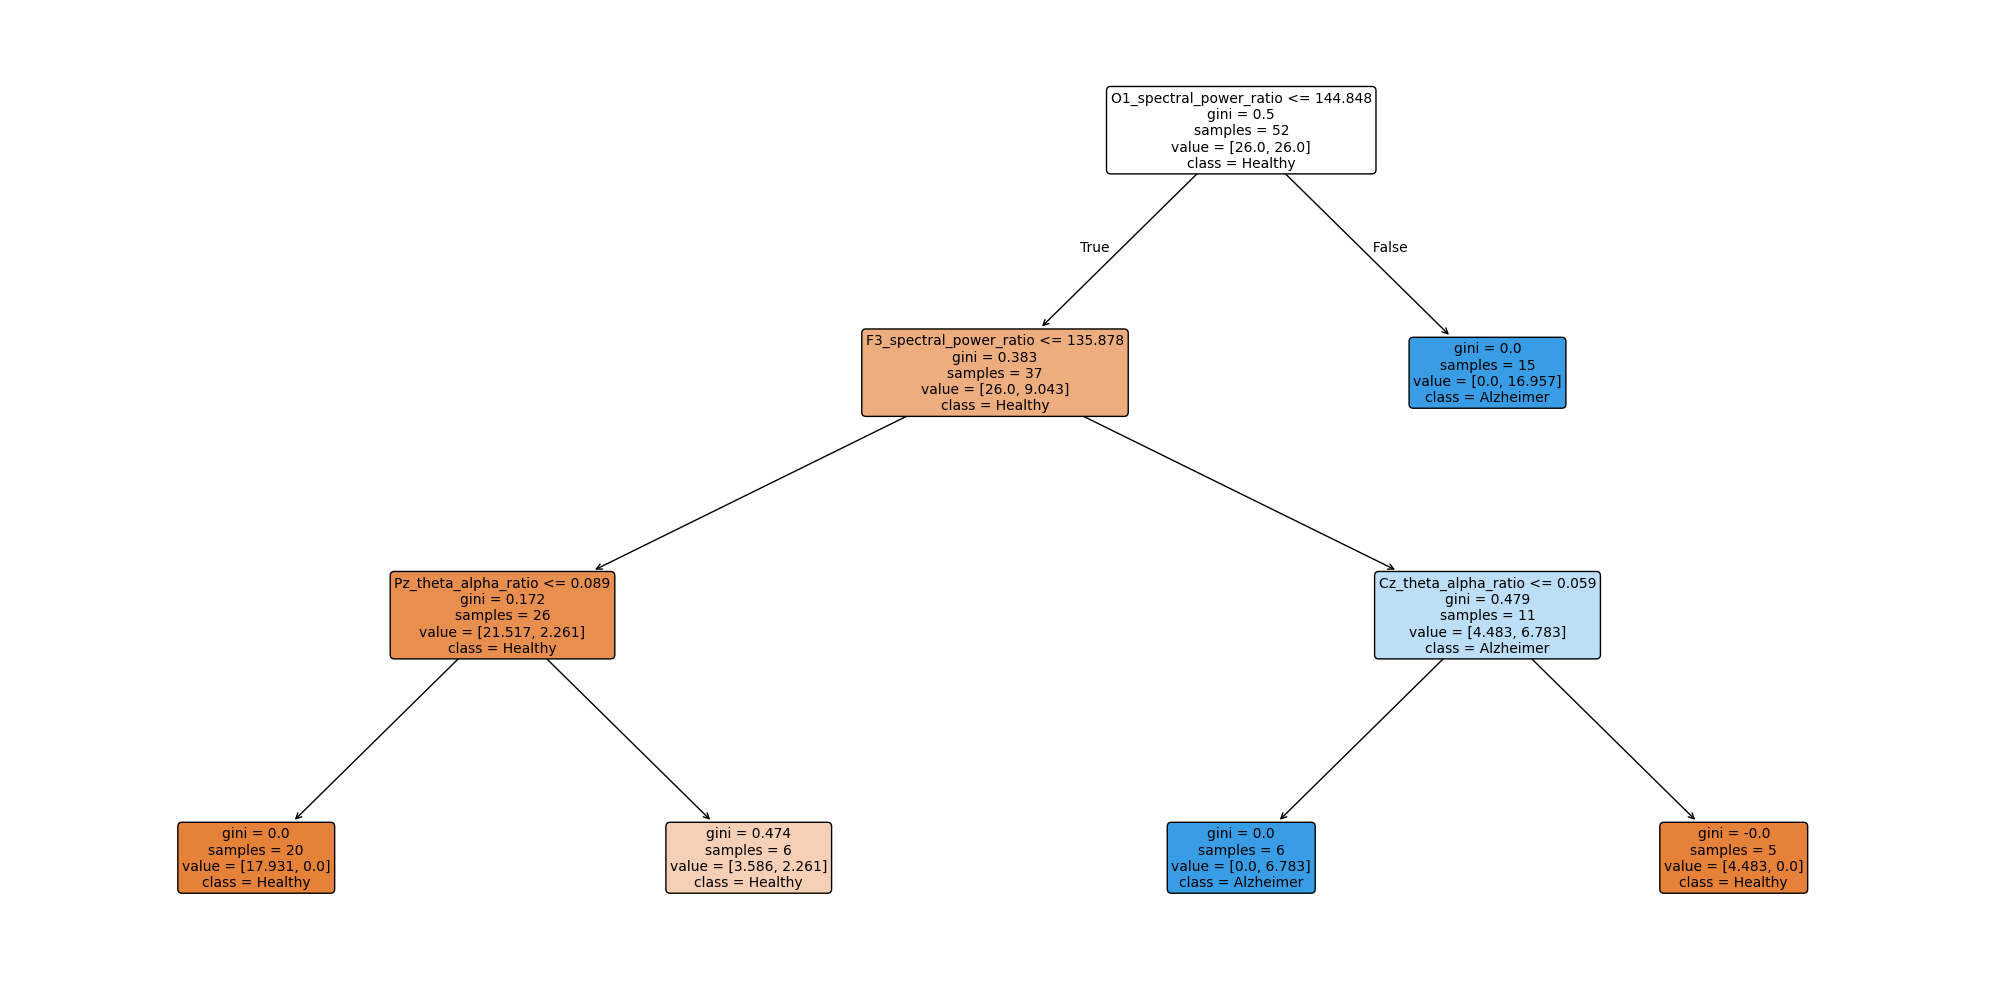

In [64]:
from prediction.decision_tree.helpers import DecisionTreeVisualization

DecisionTreeVisualization.plot(predictor)

In [69]:
y_preds = predictor.predict(test_dataset.selector.X())
y_trues = np.array(test_dataset.selector.y())

In [70]:
for y_pred, y_true in zip(y_preds, y_trues):
    print(f"Prédiction : {y_pred}; vraie valeur : {y_true}")
score= predictor.classifier.score(test_dataset.selector.X(), test_dataset.selector.y())

print(f"Score = {score}")

Prédiction : Alzheimer; vraie valeur : Alzheimer
Prédiction : Alzheimer; vraie valeur : Alzheimer
Prédiction : Alzheimer; vraie valeur : Alzheimer
Prédiction : Healthy; vraie valeur : Alzheimer
Prédiction : Healthy; vraie valeur : Alzheimer
Prédiction : Alzheimer; vraie valeur : Alzheimer
Prédiction : Alzheimer; vraie valeur : Alzheimer
Prédiction : Healthy; vraie valeur : Healthy
Prédiction : Healthy; vraie valeur : Healthy
Prédiction : Healthy; vraie valeur : Healthy
Prédiction : Healthy; vraie valeur : Healthy
Prédiction : Alzheimer; vraie valeur : Healthy
Prédiction : Alzheimer; vraie valeur : Healthy
Score = 0.6923076923076923


In [72]:
from sklearn.metrics import classification_report
print(classification_report(y_trues, y_preds))

              precision    recall  f1-score   support

   Alzheimer       0.71      0.71      0.71         7
     Healthy       0.67      0.67      0.67         6

    accuracy                           0.69        13
   macro avg       0.69      0.69      0.69        13
weighted avg       0.69      0.69      0.69        13

